# Detergent Customer Segmentation with Unsupervised Learning

## Executive Summary

This notebook turns a conjoint-style detergent pricing study into a customer segmentation exercise. The central finding is simple: **do not discount everyone**. Households show different price-response patterns, and those patterns suggest different marketing actions.

We compare several unsupervised approaches and use full price-response curves as the final segmentation model. A four-cluster solution is the most useful business choice:

| Cluster | Segment | Approx. size | Core behavior | Recommended action |
|---:|---|---:|---|---|
| 0 | Deal Hunters | 38% | Buy only at low prices | Deprioritize paid marketing; email-only or low-cost offers |
| 1 | Selective Spenders | 15% | Higher willingness to pay, moderate price sensitivity | Use differentiation, bundles, loyalty perks, and light promotions |
| 2 | Practical Value Seekers | 22% | Medium willingness to pay, responsive to value | Test 10-20% coupons and price thresholds |
| 3 | Premium Minimalists | 25% | Very high willingness to pay, low price sensitivity | Avoid discounts; focus on upsell, new launches, loyalty |

The main strategic recommendation is to focus active marketing tests on **Selective Spenders** and **Practical Value Seekers**, while protecting margin on premium customers and avoiding expensive acquisition for deeply price-sensitive customers.

## 1. Business Problem

A premium dishwasher detergent brand ran a pricing study. Each household saw the product at several prices and indicated whether it would purchase.

The business does not need one average demand curve. It needs to know whether the market contains meaningfully different customer groups. If those groups exist, the firm can improve pricing, promotion targeting, product messaging, and margin protection.

This is an unsupervised learning problem because the goal is not to predict a known label. The goal is to discover structure in customer behavior.

## 2. Data and Setup

Each row in the raw data is a household-price observation. The same household appears multiple times, once for each tested price.

Key fields:

- `purchase`: 1 if the household would buy at the shown price, 0 otherwise
- `price`: tested price
- `household_id`: household identifier
- `age`, `family_size`, `prev_interactions`: numeric household characteristics
- `income_bracket`, `state`, `sex`, `race`: categorical household characteristics

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 0

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

In [2]:
local_paths = [
    Path("pricing_application_conjoint.csv"),
    Path("Problem_Sets/PS2/pricing_application_conjoint.csv"),
]

csv_path = next((path for path in local_paths if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find pricing_application_conjoint.csv. Run this notebook from the PS2 folder or repo root.")

df_raw = pd.read_csv(csv_path)

for col in ["Unnamed: 0", "index", "Index"]:
    if col in df_raw.columns:
        df_raw = df_raw.drop(columns=col)

print(df_raw.shape)
display(df_raw.head())

(80000, 10)


,household_id,income_bracket,age,family_size,sex,prev_interactions,price,purchase,race,state
0,0,60k–70k,31,4,M,0,50,0,Black,AL
1,0,60k–70k,31,4,M,0,45,0,Black,AL
2,0,60k–70k,31,4,M,0,40,0,Black,AL
3,0,60k–70k,31,4,M,0,35,0,Black,AL
4,0,60k–70k,31,4,M,0,30,0,Black,AL


## 3. Household-Level Feature Construction

The object of segmentation should be the household, not the household-price row. Clustering rows would overweight households that appear many times and would mix customer differences with price-level differences.

We construct three representations:

1. A baseline household profile using demographics plus `reservation_price`.
2. A simple `dropoff_price`, defined as the first price where a household says no.
3. A full price-response curve, where each household is represented by purchase responses across all tested prices.

In [3]:
reservation_price = (
    df_raw.loc[df_raw["purchase"] == 1]
    .groupby("household_id")["price"]
    .max()
    .rename("reservation_price")
)

dropoff_price = (
    df_raw.loc[df_raw["purchase"] == 0]
    .groupby("household_id")["price"]
    .min()
    .rename("dropoff_price")
)

households = (
    df_raw.drop_duplicates("household_id")
    .merge(reservation_price, on="household_id", how="left")
    .merge(dropoff_price, on="household_id", how="left")
)

# Households that never buy are assigned a lower-bound observed willingness to pay.
households["reservation_price"] = households["reservation_price"].fillna(10)

curve_features = (
    df_raw.pivot_table(index="household_id", columns="price", values="purchase", aggfunc="mean")
    .fillna(0)
    .reindex(sorted(df_raw["price"].unique()), axis=1)
)

print("Household table:", households.shape)
print("Price-response matrix:", curve_features.shape)
display(households.head())
display(curve_features.head())

Household table: (10000, 12)
Price-response matrix: (10000, 8)


,household_id,income_bracket,age,family_size,sex,prev_interactions,price,purchase,race,state,reservation_price,dropoff_price
0,0,60k–70k,31,4,M,0,50,0,Black,AL,25.0,30.0
1,1,60k–70k,42,5,F,1,50,0,White,AL,15.0,20.0
2,2,60k–70k,42,5,M,1,50,0,White,AL,10.0,15.0
3,3,60k–70k,30,1,M,1,50,1,White,AL,50.0,NaN
4,4,60k–70k,61,2,M,0,50,0,White,AL,15.0,20.0


price,15,20,25,30,35,40,45,50
household_id,,,,,,,,
0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Helper Functions

The analysis uses the same diagnostic pattern across candidate models: fit K-means over a small grid of K values, inspect inertia and silhouette, then profile the resulting clusters.

In [4]:
def fit_kmeans_grid(Xmat, k_values=(3, 4, 5), random_state=RANDOM_STATE):
    rows = []
    models = {}
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=50)
        labels = model.fit_predict(Xmat)
        rows.append({
            "K": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(Xmat, labels),
        })
        models[k] = model
    return pd.DataFrame(rows), models


def plot_k_diagnostics(table, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(table["K"], table["inertia"], marker="o")
    ax[0].set_title(f"{title}: inertia")
    ax[0].set_xlabel("K")
    ax[0].set_ylabel("Inertia")
    ax[1].plot(table["K"], table["silhouette"], marker="o")
    ax[1].set_title(f"{title}: silhouette")
    ax[1].set_xlabel("K")
    ax[1].set_ylabel("Silhouette")
    plt.tight_layout()
    plt.show()


def profile_clusters(profile_df, cluster_col):
    numeric_cols = ["age", "family_size", "prev_interactions", "reservation_price"]
    out = profile_df.groupby(cluster_col)[numeric_cols].mean().round(2)
    out["cluster_size"] = profile_df[cluster_col].value_counts().sort_index()
    out["share"] = (out["cluster_size"] / len(profile_df)).round(3)
    return out


def plot_price_response(raw_df, labels_df, cluster_col, title):
    plotted = raw_df.merge(labels_df[["household_id", cluster_col]], on="household_id", how="left")
    curve = (
        plotted.groupby([cluster_col, "price"])["purchase"]
        .mean()
        .reset_index(name="purchase_rate")
    )
    plt.figure(figsize=(8, 5))
    for cluster in sorted(curve[cluster_col].dropna().unique()):
        temp = curve[curve[cluster_col] == cluster]
        plt.plot(temp["price"], temp["purchase_rate"], marker="o", label=f"Cluster {int(cluster)}")
    plt.title(title)
    plt.xlabel("Price")
    plt.ylabel("Purchase rate")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.show()

## 5. Candidate Model 1: Baseline Household-Feature K-Means

This baseline clusters households using standardized numeric features and one-hot encoded categorical features. It is useful as a starting point, but it is not the final model because the representation mixes demographics with a compressed price metric.

,K,inertia,silhouette
0,3,45856.420036,0.207850
1,4,41442.291642,0.163399
2,5,39098.717892,0.140048


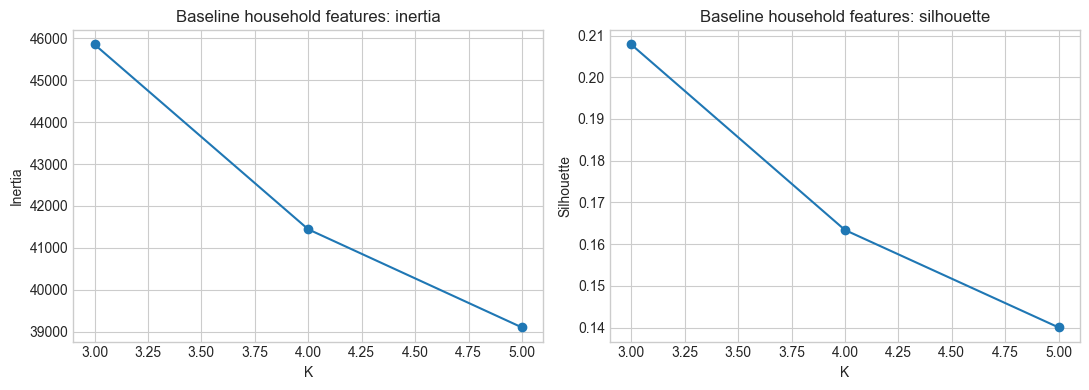

In [5]:
exclude_cols = ["purchase", "price", "household_id", "dropoff_price"]
X_household = households.drop(columns=[c for c in exclude_cols if c in households.columns]).copy()

num_cols = X_household.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_household.select_dtypes(include=["object", "string", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

X_baseline = preprocessor.fit_transform(X_household)
baseline_table, baseline_models = fit_kmeans_grid(X_baseline)
display(baseline_table)
plot_k_diagnostics(baseline_table, "Baseline household features")

## 6. Candidate Model 2: Drop-Off-Price Clustering

`dropoff_price` is the first price where a household says no. This is intuitive, but it uses only one point from the response curve. It is best treated as a robustness check rather than the final segmentation model.

,K,inertia,silhouette
0,3,863.558576,0.677142
1,4,458.722406,0.726662
2,5,243.565285,0.813814


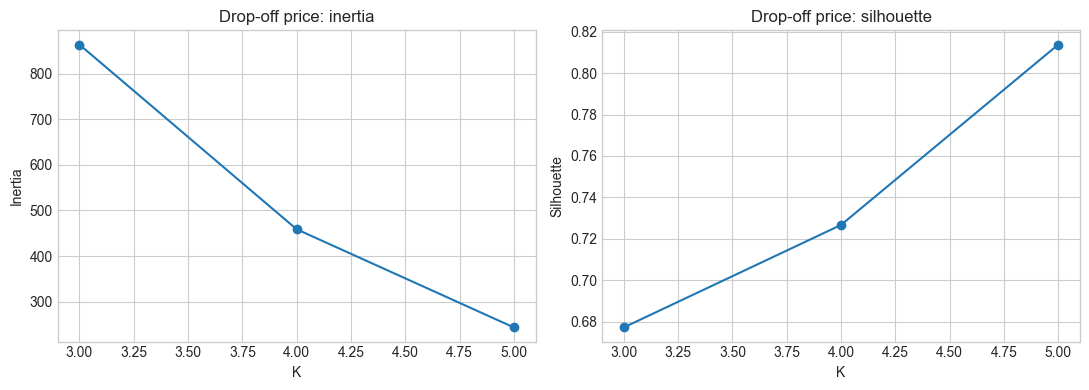

,dropoff_price,reservation_price,age,family_size
drop_cluster,,,,
0,15.00,10.00,43.73,5.30
1,44.14,39.14,37.56,2.00
2,32.09,27.09,38.16,2.64
3,22.20,17.20,40.24,3.59


In [6]:
drop_profile = households.dropna(subset=["dropoff_price"]).copy()
X_drop = StandardScaler().fit_transform(drop_profile[["dropoff_price"]])

drop_table, drop_models = fit_kmeans_grid(X_drop)
display(drop_table)
plot_k_diagnostics(drop_table, "Drop-off price")

drop_profile["drop_cluster"] = drop_models[4].labels_
display(drop_profile.groupby("drop_cluster")[["dropoff_price", "reservation_price", "age", "family_size"]].mean().round(2))

## 7. Candidate Model 3: Price-Response-Curve K-Means

This is the final model. Each household is represented by its complete purchase pattern across tested prices. This representation directly matches the business problem: pricing and promotion decisions depend on how demand changes as price changes.

,K,inertia,silhouette
0,3,3750.222644,0.608916
1,4,2389.349407,0.660925
2,5,1457.854151,0.790426


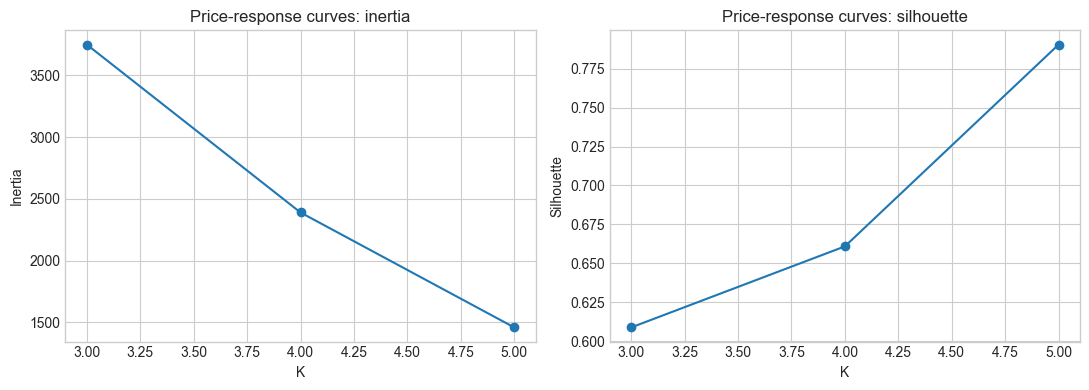

In [7]:
curve_table, curve_models = fit_kmeans_grid(curve_features, k_values=(3, 4, 5))
display(curve_table)
plot_k_diagnostics(curve_table, "Price-response curves")

### Choosing K: Why 4, Not 3 or 5

K is a business judgment as well as a statistical choice.

- **K = 3 is too coarse.** It combines middle customers with different willingness to pay, which would lead to overly broad targeting.
- **K = 5 adds complexity without enough new actionability.** It mostly splits already price-sensitive customers into smaller low-price groups.
- **K = 4 gives the best operating structure.** It separates four groups with distinct price-response behavior and clear marketing actions.

In [8]:
k_profiles = []
for k, model in curve_models.items():
    temp = households.copy()
    temp["cluster"] = model.labels_
    p = profile_clusters(temp, "cluster").reset_index()
    p.insert(0, "K", k)
    k_profiles.append(p)

display(pd.concat(k_profiles, ignore_index=True))

,K,cluster,age,family_size,prev_interactions,reservation_price,cluster_size,share
0,3,0,38.60,2.79,0.46,25.53,3355,0.336
1,3,1,33.69,1.44,0.43,48.13,2851,0.285
2,3,2,42.58,4.68,0.45,12.17,3794,0.379
3,4,0,42.58,4.68,0.45,12.17,3794,0.379
4,4,1,37.74,2.23,0.44,34.12,1537,0.154
5,4,2,38.92,3.04,0.46,22.08,2205,0.220
6,4,3,33.17,1.35,0.44,49.41,2464,0.246
7,5,0,43.73,5.30,0.47,10.00,2151,0.215
8,5,1,33.17,1.35,0.44,49.41,2464,0.246
9,5,2,38.92,3.04,0.46,22.08,2205,0.220


## 8. Final Four-Segment Solution

The final segmentation uses K=4 on full price-response curves.

,segment,cluster_size,share,age,family_size,prev_interactions,reservation_price
segment_id,,,,,,,
0,Deal Hunters,3794,0.379,42.58,4.68,0.45,12.17
1,Selective Spenders,1537,0.154,37.74,2.23,0.44,34.12
2,Practical Value Seekers,2205,0.220,38.92,3.04,0.46,22.08
3,Premium Minimalists,2464,0.246,33.17,1.35,0.44,49.41


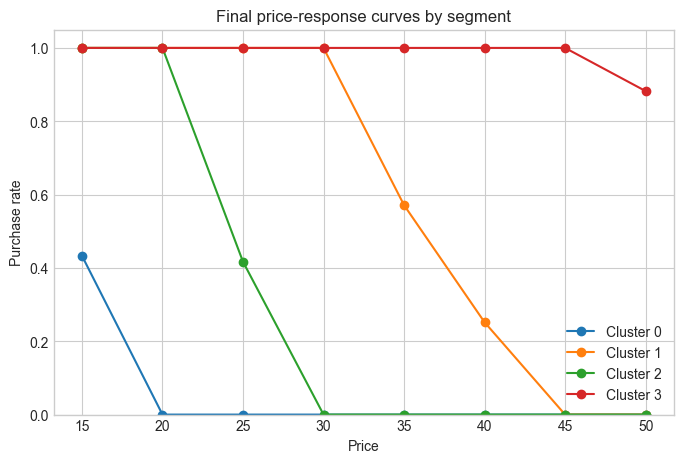

In [9]:
final_model = curve_models[4]
curve_profile = households.copy()
curve_profile["segment_id"] = final_model.labels_

segment_names = {
    0: "Deal Hunters",
    1: "Selective Spenders",
    2: "Practical Value Seekers",
    3: "Premium Minimalists",
}
curve_profile["segment"] = curve_profile["segment_id"].map(segment_names)

segment_profile = profile_clusters(curve_profile, "segment_id")
segment_profile["segment"] = segment_profile.index.map(segment_names)
segment_profile = segment_profile[["segment", "cluster_size", "share", "age", "family_size", "prev_interactions", "reservation_price"]]
display(segment_profile)

plot_price_response(df_raw, curve_profile.rename(columns={"segment_id": "cluster"}), "cluster", "Final price-response curves by segment")

### Segment Interpretation

- **Cluster 0: Deal Hunters**
  - Largest group, low reservation price, older on average, larger families.
  - Highly price sensitive; paid targeting is unlikely to be efficient.
- **Cluster 1: Selective Spenders**
  - Smaller group, high willingness to pay, smaller households.
  - Good target for differentiation, bundles, loyalty perks, and light promotions.
- **Cluster 2: Practical Value Seekers**
  - Medium willingness to pay and medium family size.
  - Best group for testing 10-20% coupons and threshold pricing.
- **Cluster 3: Premium Minimalists**
  - Youngest and smallest households on average, highest reservation price.
  - Avoid discounts; prioritize upsell, subscriptions, new launches, and loyalty.

## 9. Candidate Model 4: GMM Robustness Check

K-means creates hard assignments: every household belongs to exactly one segment. A Gaussian Mixture Model allows a more flexible probabilistic view. We use it as a robustness check, not as the final business segmentation.

In [10]:
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE, reg_covar=1e-6)
gmm_labels = gmm.fit_predict(curve_features)

gmm_compare = pd.DataFrame({
    "household_id": curve_features.index,
    "kmeans_segment": final_model.labels_,
    "gmm_segment": gmm_labels,
})

display(pd.crosstab(gmm_compare["kmeans_segment"], gmm_compare["gmm_segment"]))

gmm_segment,0,1,2,3
kmeans_segment,,,,
0,0,1643,0,2151
1,387,0,1150,0
2,0,1286,919,0
3,2464,0,0,0


The broad structure is stable: the market separates into premium, value-oriented, and highly price-sensitive households. The exact boundaries of middle segments are less stable, which is why those groups should be treated as test-and-learn targets rather than fixed customer identities.

## 10. PCA Visualization

PCA is used as a visualization and sanity check. It does not prove that the clusters are objectively true, but it shows whether most price-response variation can be summarized in a low-dimensional space.

Explained variance ratio: [0.698 0.149]


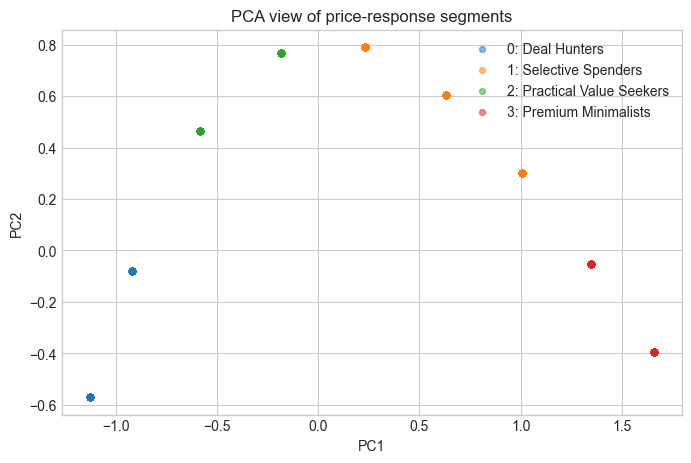

In [11]:
pca = PCA(n_components=2)
curve_pca = pca.fit_transform(curve_features)

pca_df = pd.DataFrame(curve_pca, columns=["PC1", "PC2"])
pca_df["segment_id"] = final_model.labels_
pca_df["segment"] = pca_df["segment_id"].map(segment_names)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

plt.figure(figsize=(8, 5))
for segment_id, segment_name in segment_names.items():
    temp = pca_df[pca_df["segment_id"] == segment_id]
    plt.scatter(temp["PC1"], temp["PC2"], s=18, alpha=0.5, label=f"{segment_id}: {segment_name}")
plt.title("PCA view of price-response segments")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## 11. Marketing Strategy

The strategy is not to maximize purchase volume at any cost. The strategy is to use segmentation to avoid wasted discounts and focus tests where customers are influenceable.

| Segment | Marketing strategy | Rationale |
|---|---|---|
| Deal Hunters | Deprioritize paid media; use email-only or very low-cost offers | Deep discounts may create volume but risk poor margin |
| Selective Spenders | Product differentiation, premium-lite bundles, loyalty perks, light promos | They have higher willingness to pay and should not receive unnecessary deep discounts |
| Practical Value Seekers | Test 10-20% coupons and price thresholds | They are value-sensitive but not purely low-price customers |
| Premium Minimalists | Avoid discounts; use upsell, subscriptions, launches, loyalty | They already show high willingness to pay |

Before rollout, the firm should validate recommendations using actual transaction data and controlled A/B tests. The key metric should be incremental profit, not purchase lift alone.

## 12. Caveats and Next Steps

- The data reflects stated purchase intent, not actual purchases.
- Discounts should be evaluated using margin and incremental profit.
- Segment membership must be predicted from observable signals before deployment.
- K=4 is an actionability choice, not a universal truth.
- Future improvements should add transaction history, coupon redemption, channel, geography, competitor pricing, and product margin.